In [1]:
# Import Python libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

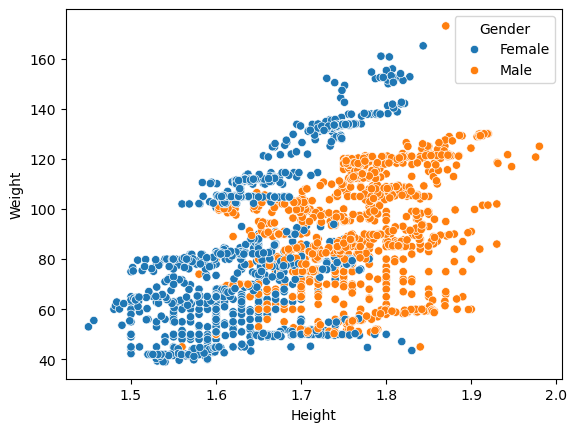

In [2]:
# Import and visualise gender dataset based on heights and weights (i.e., independent variables)
df = pd.read_csv("gender_data.csv", usecols=["Gender", "Height", "Weight"])
sns.scatterplot(data=df, x="Height", y="Weight", hue="Gender")
plt.show()

In [3]:
# Preprocessing
encoder = OrdinalEncoder(categories=[["Female", "Male"]]) # Female = 0, Male = 1
df["Gender_Code"] = encoder.fit_transform(df[["Gender"]])

df["Height_Norm"] = (df["Height"] - df["Height"].mean()) / df["Height"].std(ddof=0)
df["Weight_Norm"] = (df["Weight"] - df["Weight"].mean()) / df["Weight"].std(ddof=0)

## Break into train-test sets
X = df[["Height", "Weight"]]
y = df["Gender_Code"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=11)

In [4]:
# Logistic Regression

## Fit the pipeline to both train and test sets
pipe = make_pipeline(StandardScaler(), LogisticRegression())
pipe.fit(X_train, y_train)
lr_score = round(pipe.score(X_test, y_test) * 100, 2)
print(f"Logistic Regression Accuracy: {lr_score}%")

Logistic Regression Accuracy: 76.36%


In [5]:
# K-Nearest Neighbour

## Perform 5-fold cross validation for each k value
k_vals = range(1, 40, 2)
cv_scores = []
for k in k_vals: # Use odd values to prevent tie
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

## Find optimal k
idx = np.argmax(cv_scores)
best_k = k_vals[idx]
print(f"The optimal k value is {best_k}")

## Fit the pipeline to both train and test sets
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
pipe.fit(X_train, y_train)
knn_score = round(pipe.score(X_test, y_test) * 100, 2)
print(f"K-Nearest Neighbor Accuracy: {knn_score}%") 

The optimal k value is 7
K-Nearest Neighbor Accuracy: 87.23%


In [6]:
# Support Vector Machine

## Perform 5-fold cross validation 
param_grid = [
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": [1e-3, 1e-4, "scale"]
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__degree": [3, 4],
        "svc__coef0": [0.0, 0.1, 0.5]
    }
]
pipe = make_pipeline(StandardScaler(), SVC(random_state=11))
grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5, verbose=2, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)
gs_params = grid_search.best_params_
print(f"Best parameters found: {gs_params}")

## Fit the pipeline to both train and test sets
if len(gs_params) == 3: # RBF
    best_C, best_gamma, best_kernel = gs_params["svc__C"], gs_params["svc__gamma"], gs_params["svc__kernel"]
    pipe = make_pipeline(StandardScaler(), SVC(kernel=best_kernel, C=best_C, gamma=best_gamma))
else: # Polynomial
    best_C, best_degree, best_coef0, best_kernel = gs_params["svc__C"], gs_params["svc__degree"], gs_params["svc__coef0"], gs_params["svc__kernel"]
    pipe = make_pipeline(StandardScaler(), SVC(kernel=best_kernel, C=best_C, degree=best_degree, coef0=best_coef0))
pipe.fit(X_train, y_train)
svm_score = round(pipe.score(X_test, y_test) * 100, 2)
print(f"SVM Accuracy: {svm_score}%") 

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
SVM Accuracy: 86.52%


In [7]:
# Neural Network

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def deriv_sigmoid(x):
    return x * (1 - x)

class myNeuralNet:
    """ 
    Simple Neural Network with one hidden layer.
    """
    def __init__(self, inputs, outputs=None, hidden_size=2, lr=0.1):
        self.inputs = np.array(inputs)
        self.input_size = inputs.shape[1]
        self.outputs = np.array(outputs) if outputs is not None else np.zeros((len(self.inputs), 1))
        self.output_size = 1

        np.random.seed(42)
        self.W1 = np.random.randn(self.input_size, hidden_size) # W1 contains the weights of all inputs.
        self.B1 = np.zeros((1, hidden_size)) # B1 contains all the bias for hidden layer neurons.
        self.W2 = np.random.randn(hidden_size, self.output_size) # W1 contains the weights of hidden layer neurons.
        self.B2 = np.zeros((1, self.output_size)) # B2 contains all the bias for output neurons.
        
        self.lr = lr
        
    def f_pass(self, inputs):
        self.hidden = sigmoid( np.matmul(inputs, self.W1) + self.B1 )
        self.preds = sigmoid( np.matmul(self.hidden, self.W2) + self.B2 )
        return self.preds

    def b_pass(self, inputs, outputs):
        # Outer / Prediction layer
        ## L = 0.5*( (self.preds - outputs)**2 ) # Squared-error loss; 0.5 is used as a math convenience.
        ## We want to minimize the loss function with respect to the weights used in outer layer, i.e., dL/dW2. 
        ## Since preds is sigmoid function of W2, differentiating it would return the sigmoid derivative. 
        ## Applying chain rule: dL/dW2 = dL/d(preds) * d(preds)/dW2
        dLdW2 =  (self.preds - outputs) * deriv_sigmoid(self.preds)

        # Hidden layer
        ## Traversing back, we want to minimize the loss function with respect to the weights used in hidden layer, i.e., dL/dW1. 
        ## For a hidden neuron in the hidden layer, it takes the weighted "blame" of the outer layer error.  
        ## Since hidden is sigmoid function of W1, differentiating it would return the sigmoid derivative. 
        ## Applying chain rule: dL/dW1 = dL/dW2 * W2 * d(hidden)/dW1 
        dLdW1 = np.matmul(dLdW2, self.W2.T) * deriv_sigmoid(self.hidden)

        # SGD weight updates
        self.W2 -= self.lr * np.matmul(self.hidden.T, dLdW2)
        self.B2 -= self.lr * np.sum(dLdW2, axis=0, keepdims=True)
        self.W1 -= self.lr * np.matmul(inputs.T, dLdW1)
        self.B1 -= self.lr * np.sum(dLdW1, axis=0, keepdims=True)

    def train(self, inputs, outputs, epochs=10000):
        for epoch in range(epochs):
            self.f_pass(inputs)
            self.b_pass(inputs, outputs)
            if epoch % 500 == 0:
                preds = self.f_pass(X)
                loss = np.mean((preds - y) ** 2) # Measures Mean Squared Error
                print(f"Epoch #{epoch} - Loss: {loss:.4f}")


In [8]:
X_train, X_test, y_train, y_test = train_test_split(df[["Height_Norm", "Weight_Norm"]], df[["Gender_Code"]], train_size=0.8)
net = myNeuralNet(X_train, y_train, lr=0.01)
net.train(net.inputs, net.outputs, epochs=10**4)

Epoch #0 - Loss: 0.3392
Epoch #500 - Loss: 0.0009
Epoch #1000 - Loss: 0.0010
Epoch #1500 - Loss: 0.0014
Epoch #2000 - Loss: 0.0019
Epoch #2500 - Loss: 0.0028
Epoch #3000 - Loss: 0.0024
Epoch #3500 - Loss: 0.0020
Epoch #4000 - Loss: 0.0017
Epoch #4500 - Loss: 0.0014
Epoch #5000 - Loss: 0.0011
Epoch #5500 - Loss: 0.0009
Epoch #6000 - Loss: 0.0007
Epoch #6500 - Loss: 0.0006
Epoch #7000 - Loss: 0.0005
Epoch #7500 - Loss: 0.0004
Epoch #8000 - Loss: 0.0004
Epoch #8500 - Loss: 0.0003
Epoch #9000 - Loss: 0.0003
Epoch #9500 - Loss: 0.0002


In [9]:
# Apply to test set
results = net.f_pass(np.array(X_test))
preds = (results > 0.5).astype(int)

# Calculate accuracy and overall best model
nn_score = round( np.mean(preds == np.array(y_test))*100, 2)
print(f"NN Accuracy: {nn_score}%")
scores = {
    "Logistic Regression": lr_score,
    "K-Nearest Neighbor": knn_score,
    "Support Vector": svm_score,
    "Neural Network": nn_score
}
best_model, best_score = max(scores.items(), key=lambda x: x[1])
print(f"Best Model: {best_model} with {best_score}% accuracy.")

NN Accuracy: 85.58%
Best Model: K-Nearest Neighbor with 87.23% accuracy.


In [10]:
scores

{'Logistic Regression': 76.36,
 'K-Nearest Neighbor': 87.23,
 'Support Vector': 86.52,
 'Neural Network': 85.58}